In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats

import pyunfold as pu

In [2]:
def T(A):
    return np.swapaxes(A, -2, -1)

In [3]:
Prop = Propagator()
density_model = ('MSIS00', ('SouthPole', 'January'))
tag = 'DomeC'

In [4]:
df_Pfast = pd.read_csv('Production Rates/P_fast_SouthPole_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_SouthPole_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [5]:
# The only production model being used is Heisinger
i = model_names.index('Heisinger')
prod_cut = np.arange(len(P_14C))[i:i+1]

In [6]:
Prop.Phi['prod']=P_14C[prod_cut]
C_flow_response = F.flow_14C_response(Prop)
C_response = C_flow_response @ Prop.S_mat[Prop.i_start:]

In [7]:
np.shape(C_response)

(1, 2, 7283, 10)

In [335]:
# SET TIME-DEPENDENT FLUX MODEL

t_bins = Prop.t_bins[Prop.i_start:]-Prop.t_bins[-1] # time in years, with 0=present
t = Prop.t[Prop.i_start:]-Prop.t_bins[-1]
t_scale = t/-t_bins[0] # time scaled from -1 to 0, with 0=present
t_bins_scale = (t_bins/-t_bins[0]).reshape((1,-1))
dt_bins_scale = np.diff(t_bins_scale,axis=-1)

N_step = 100

#t_step = np.reshape(np.linspace(-1., 0., N_step+1), (-1,1))
#f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale))/dt_bins_scale
t_step = np.reshape(np.arange(-1.,2./(N_step-1),1./(N_step-1)), (-1,1))
f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)))*(N_step-1)

N_interp = 6

t_step = np.reshape(np.arange(-1.,2./(N_interp-1),1./(N_interp-1)), (-1,1))
f_interp = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_interp-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_interp-1)))*(N_interp-1)

In [138]:
dc = 10.
gauss_centers = np.arange(t_bins[0], t_bins[-1]+dc, dc)
dw = 100.
gauss_widths = np.arange(dw, Prop.t_bins[-1]+dw, dw)
f_gauss = np.exp(-((t.reshape((1,1,-1))-gauss_centers.reshape((-1,1,1)))/gauss_widths.reshape((1,-1,1)))**2/2)/gauss_widths.reshape((1,-1,1))/np.sqrt(2*np.pi)
#axis0 - gaussian center
#axis1 - gaussian width
#axis2 - integration time
f_gauss /= np.sum(f_gauss, axis=-1, keepdims=True)

In [336]:
C_flow_step = np.swapaxes(f_step @ C_flow_response, 1,2)
C_flow_interp = np.swapaxes(f_interp @ C_flow_response, 1,2)

In [141]:
#C_flow_gauss = np.moveaxis([f @ C_flow_response for f in tqdm(f_gauss)], (0,2), (1,-2))

100%|█████████████████████████████████████████████████████████████████████████████████| 730/730 [01:13<00:00,  9.92it/s]


In [337]:
C_step = np.swapaxes(f_step @ C_response, 1,2)
C_interp = np.swapaxes(f_interp @ C_response, 1,2)

In [143]:
C_gauss = np.moveaxis([f @ C_response for f in tqdm(f_gauss)], (0,2), (1,-2))

100%|████████████████████████████████████████████████████████████████████████████████| 730/730 [00:03<00:00, 217.16it/s]


In [144]:
rel_err = 0.02
#rel_err = 0.

In [343]:
f_true = np.array([0.08,0.06])
CO_avg_interp = f_true @ C_interp
CO_avg_flow_interp = f_true @ C_flow_interp

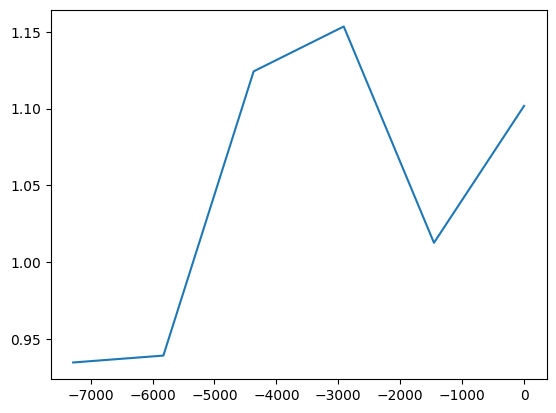

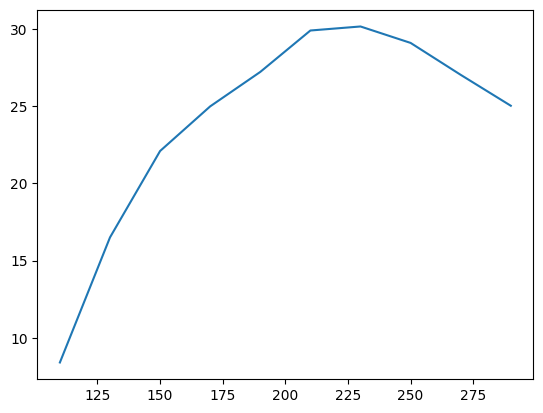

In [466]:
CO_samp = CO_avg_interp[0]

N = 1
amp = 0.2
s = np.random.normal(0,rel_err,(N, np.shape(CO_samp)[-1]))
f_samp = np.random.rand(np.shape(CO_samp)[-2])*amp*2+1-amp
#f_samp = np.ones(len(Prop.z_samp))
#x = CO_avg_poly[0,0]*(1+s)
x = (f_samp @ CO_samp)*(1+s)

plt.plot(t,f_samp @ f_interp)
plt.show()

plt.plot(Prop.z_samp, x[0])
plt.show()

In [467]:
da = 20.
a = np.arange(-2000., 2000+da, da)

CO_exp = x[0]
CO_err = x[0]*rel_err

Sigma = np.diag(CO_err**2)
Sigma_inv = np.linalg.inv(Sigma)

C0 = np.sum(C_response, axis=-2)
C_pred = C0.reshape((-1,1,1,1,2,10)) + a.reshape((1,-1,1,1,1,1))*np.expand_dims(C_gauss, axis=1)
# axis0 - production model
# axis1 - amplitude
# axis2 - center
# axis3 - width
# axis4 - production mode (pos, neg)
# axis5 - sample depth

f_hat = np.linalg.inv(C_pred @ Sigma_inv @ T(C_pred)) @ C_pred @ Sigma_inv @ CO_exp

In [468]:
np.shape(C_pred)

(1, 201, 730, 98, 2, 10)

In [469]:
np.shape(f_hat)

(1, 201, 730, 98, 2)

In [470]:
CO_pred = np.sum(f_hat.reshape((*np.shape(f_hat),1)) * C_pred, axis=-2) 
chi2 = np.sum((CO_pred - CO_exp) @ Sigma_inv *(CO_pred - CO_exp), axis=-1)
chi2[np.min(f_hat, axis=-1)<0.] = np.inf
chi2[np.min(f_hat, axis=-1)>0.3] = np.inf
chi2_c = np.min(chi2, axis=(0,-1))
p_c = stats.chi2.sf(chi2_c, len(CO_exp)-len(f_hat)-3)
sig_c = stats.norm.isf(p_c/2.)
L = np.exp(-chi2/2) / np.sqrt(np.linalg.det(2*np.pi*Sigma))
P_c = np.sum(L, axis=(0,-1))/len(gauss_widths)

In [471]:
np.shape(f_gauss)

(730, 98, 7283)

amplitude: 1100.0
center: -3943.0
width: 1200.0

chi2_true = 11.089819145426393
p_true = 0.3505632335261773
sig_true = 0.9334973587751841

chi2_null = 36.5659044706146
p_null = 3.1450475523488016e-05
sigma_null = 4.1627012373865035

chi2_best = 2.785302419305514
p_best = 0.8352708736875041
sigma_best = 0.2079463299693893

f_true = [0.08 0.06]
f_hat_null = [0.08214013 0.06857099]
f_hat = [0.03832273 0.11250978]


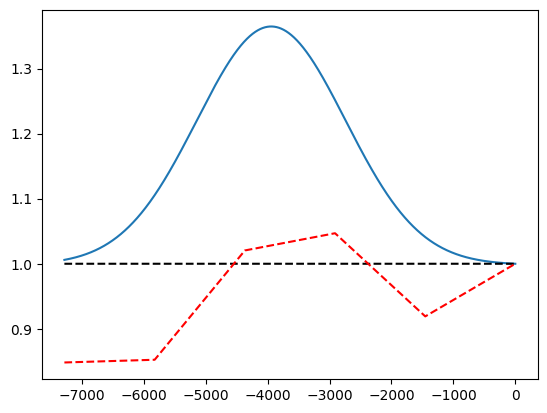

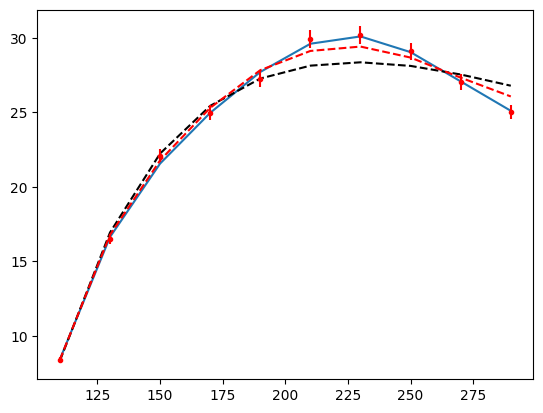

In [472]:
i_p, i_a, i_c, i_w = np.unravel_index(chi2.argmin(), chi2.shape)
i_a0 = np.arange(len(a))[a==0.][0]

#i_a = 0
print('amplitude: {}'.format(a[i_a]))
#i_c = -1
print('center: {}'.format(gauss_centers[i_c]))
#i_w = 10
print('width: {}'.format(gauss_widths[i_w]))
print()

chi2_true = np.sum((s/rel_err)**2)
p_true = stats.chi2.sf(chi2_true, len(CO_exp))
sig_true = stats.norm.isf(p_true/2.)
print('chi2_true = {}'.format(chi2_true))
print('p_true = {}'.format(p_true))
print('sig_true = {}'.format(sig_true))
print()

chi2_null = chi2[i_p, i_a0, 0,0]
p_null = stats.chi2.sf(chi2[0,i_a0,0,0], len(CO_exp)-len(f_hat))
sig_null = stats.norm.isf(p_null/2.)

print('chi2_null = {}'.format(chi2_null))
print('p_null = {}'.format(p_null))
print('sigma_null = {}'.format(sig_null))
print()

print('chi2_best = {}'.format(chi2_c[i_a,i_c]))
print('p_best = {}'.format(p_c[i_a,i_c]))
print('sigma_best = {}'.format(sig_c[i_a,i_c]))
print()

f_hat_null = f_hat[i_p,i_a0,0,0]
print('f_true = {}'.format(f_true))
print('f_hat_null = {}'.format(f_hat_null))
print('f_hat = {}'.format(f_hat[i_p,i_a,i_c,i_w]))

plt.plot(t, (1+a[i_a]*f_gauss[i_c,i_w]) / (1+a[i_a]*f_gauss[i_c,i_w])[-1])
plt.plot(t, t*0. + 1., ls='--', c='k')
plt.plot(t,f_samp @ f_interp / (f_samp @ f_interp)[-1], ls='--', c='r')
plt.show()


plt.plot(Prop.z_samp, f_hat[i_p,i_a,i_c,i_w] @ C_pred[i_p,i_a,i_c,i_w])
plt.plot(Prop.z_samp, f_hat[i_p,i_a0,0,0] @ C_pred[i_p,i_a0,0,0], ls='--', c='k')
plt.plot(Prop.z_samp, f_samp @ CO_samp, ls='--', c='r')
plt.errorbar(Prop.z_samp, CO_exp, yerr=CO_err, fmt='.', c='r')
plt.show()

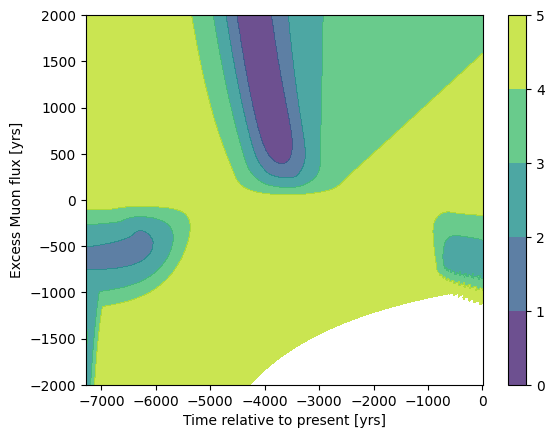

In [473]:
plt.contourf(gauss_centers, a, sig_c, alpha=0.8, levels=np.arange(6))
plt.colorbar()
plt.xlabel('Time relative to present [yrs]')
plt.ylabel('Excess Muon flux [yrs]')
plt.show()

In [474]:
np.min(sig_c)

np.float64(0.2079463299693893)

In [475]:
#plt.contourf(gauss_centers, a, p_c, alpha=0.8)
#plt.colorbar()
#plt.show()

In [476]:
#np.max(p_c)

In [477]:
#plt.plot(gauss_centers, chi2_c.T)
#plt.contourf(gauss_centers, a, chi2_c, alpha=0.8)
#plt.colorbar()
#plt.show()

In [478]:
#np.min(chi2_c)

In [479]:
#plt.contourf(gauss_centers, a, P_c, alpha=0.8)
#plt.colorbar()
#plt.show()

In [480]:
#np.max(P_c)

In [481]:
CO_avg_step = f_hat_null @ C_step
CO_avg_flow_step = f_hat_null @ C_flow_step

In [482]:
R = CO_avg_step[0].T

unfold_results = [pu.iterative_unfold(
    data = X,
    data_err = X*rel_err,
    response = R,
    response_err = np.sqrt(abs(R))*0.,
    efficiencies = np.sum(R,axis=0),
    efficiencies_err = np.sum(R,axis=0)*rel_err,
    #callbacks=[pu.Logger()],
    ts_stopping = 0.0001
) for X in x]

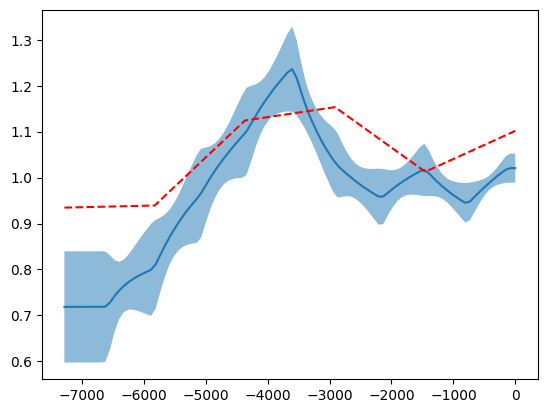

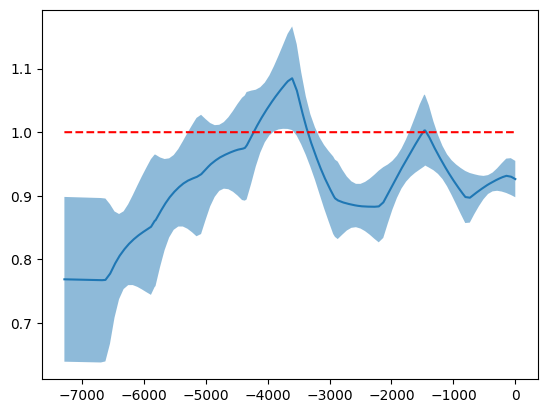

In [483]:
f_pred = f_samp @ f_interp

for u in unfold_results[:1]:
    #plt.plot(t, u['unfolded'] @ f_step)
    u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
    plt.fill_between(t, (u['unfolded']- u_err) @ f_step, (u['unfolded']+ u_err) @ f_step, alpha=0.5)
    plt.plot(t, u['unfolded'] @ f_step)
plt.plot(t, f_pred, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()

for u in unfold_results[:1]:
    #plt.plot(t, u['unfolded'] @ f_step)
    u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
    plt.fill_between(t, (u['unfolded']- u_err) @ f_step / f_pred, (u['unfolded']+ u_err) @ f_step / f_pred, alpha=0.5)
    plt.plot(t, u['unfolded'] @ f_step / f_pred)
plt.plot(t, f_pred/f_pred, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()

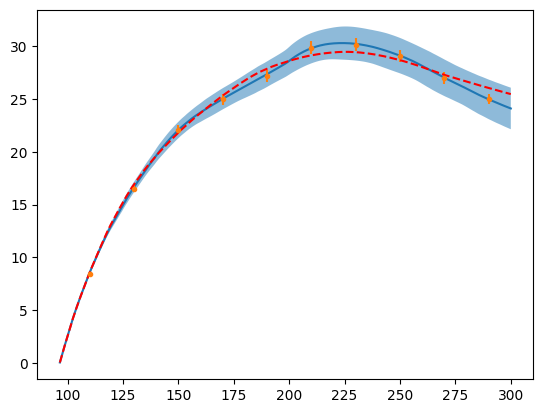

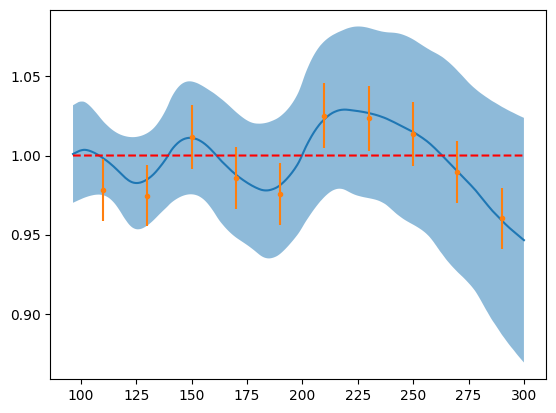

In [484]:
c_pred = f_samp @ CO_avg_flow_interp[0]
z = Prop.z[Prop.i_start:]
z_samp = Prop.z_samp

for i,u in enumerate(unfold_results[:1]):
    u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
    plt.fill_between(z, (u['unfolded']-u_err) @ CO_avg_flow_step[0], (u['unfolded']+u_err) @ CO_avg_flow_step[0], alpha=0.5)
    plt.plot(z, u['unfolded'] @ CO_avg_flow_step[0])
    plt.errorbar(z_samp, x[i], yerr=x[i] *0.02, fmt='.')
plt.plot(z, c_pred, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()

for i,u in enumerate(unfold_results[:1]):
    u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
    plt.fill_between(z, (u['unfolded']-u_err) @ CO_avg_flow_step[0]  / c_pred, (u['unfolded']+u_err) @ CO_avg_flow_step[0]  / c_pred, alpha=0.5)
    plt.plot(z, u['unfolded'] @ CO_avg_flow_step[0] / c_pred)
    plt.errorbar(z_samp, x[i] / np.interp(z_samp, z, c_pred), yerr=x[i] *rel_err /np.interp(z_samp, z, c_pred), fmt='.')
plt.plot(z, c_pred/c_pred, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()